In [3]:
import pandas as pd
import numpy as np 
import plotly.express as px 
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os
import glob

In [5]:
folder=r"E:\SQL Taks\Dataa Handling\Uber_data"
files_2014=[
    "uber-raw-data-apr14.csv",
    "uber-raw-data-may14.csv",
    "uber-raw-data-jun14.csv",
    "uber-raw-data-jul14.csv",
    "uber-raw-data-aug14.csv",
    "uber-raw-data-sep14.csv"
]
df=pd.concat(
    [pd.read_csv(os.path.join(folder,f)) for f in files_2014],
    ignore_index=True)
df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [18]:
df.tail(40)

,Date/Time,Lat,Lon,Base,Hour
4534287,2014-09-30 22:46:00,40.7225,-74.0016,B02764,22
4534288,2014-09-30 22:47:00,40.7628,-73.9713,B02764,22
4534289,2014-09-30 22:47:00,40.7606,-73.9995,B02764,22
4534290,2014-09-30 22:47:00,40.7212,-74.0048,B02764,22
4534291,2014-09-30 22:47:00,40.7212,-74.0048,B02764,22
4534292,2014-09-30 22:47:00,40.8654,-73.8671,B02764,22
4534293,2014-09-30 22:47:00,40.8080,-73.9638,B02764,22
4534294,2014-09-30 22:48:00,40.7340,-74.0052,B02764,22
4534295,2014-09-30 22:48:00,40.7329,-73.9960,B02764,22
4534296,2014-09-30 22:49:00,40.7366,-73.9868,B02764,22


In [9]:
df.to_csv("Apr14-Sep14.csv")

In [10]:
df.shape

(4534327, 4)

In [11]:
df.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='object')

In [12]:
df["Date/Time"]=pd.to_datetime(df["Date/Time"])

In [49]:
df.dtypes

Date/Time     datetime64[ns]
Lat                  float64
Lon                  float64
Base                  object
Hour                   int32
day                   object
Month                  int32
Month_name            object
day_type              object
dtype: object

In [14]:
df["Hour"]=df["Date/Time"].dt.hour

In [15]:
df.head(3)

,Date/Time,Lat,Lon,Base,Hour
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0


In [16]:
hourly_distribution=df["Hour"].value_counts().sort_index()
hourly_distribution

Hour
0     103836
1      67227
2      45865
3      48287
4      55230
5      83939
6     143213
7     193094
8     190504
9     159967
10    159148
11    165703
12    170452
13    195877
14    230625
15    275466
16    313400
17    336190
18    324679
19    294513
20    284604
21    281460
22    241858
23    169190
Name: count, dtype: int64

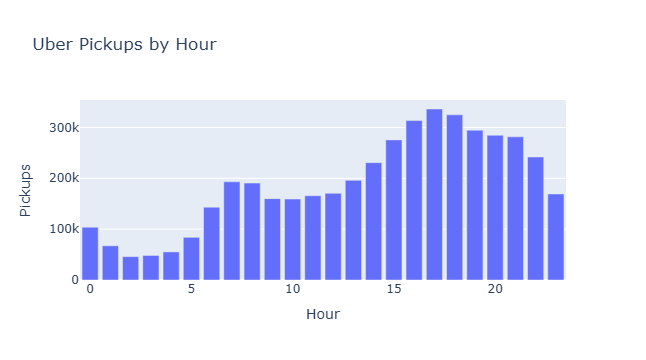

In [19]:
## Q1: How are Uber pickups distributed across different hours of the day?
hourly_dis=df.groupby('Hour').size().reset_index(name='Pickups')
fig=px.bar(
    hourly_dis,
    x='Hour',
    y='Pickups',
    title="Uber Pickups by Hour")
fig.show()

In [20]:
## Q2: How does Uber pickup volume vary across days of the week?
df['day']=df['Date/Time'].dt.day_name()

In [26]:
day_distribution = df.groupby('day').size().reset_index(name='Pickups')
day_distribution

,day,Pickups
0,Friday,741139
1,Monday,541472
2,Saturday,646114
3,Sunday,490180
4,Thursday,755145
5,Tuesday,663789
6,Wednesday,696488


In [23]:
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_distribution['day']=pd.Categorical(
    day_distribution['day'],
    categories=day_order,
    ordered=True)

day_distribution=day_distribution.sort_values('day')

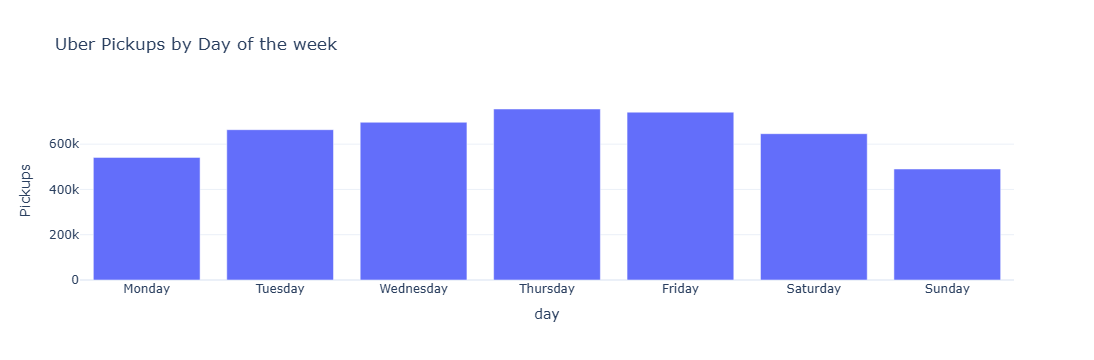

In [25]:
fig=px.bar(
    day_distribution,
    x='day',
    y='Pickups',
    title="Uber Pickups by Day of the week")
fig.update_layout(template='plotly_white')
fig.show()

In [33]:
## Q3: How does pickup activity change across different months?
df['Month']=df['Date/Time'].dt.month
df['Month_name']=df['Date/Time'].dt.month_name()

In [34]:
df.head(3)

,Date/Time,Lat,Lon,Base,Hour,day,Month,Month_name
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,Tuesday,4,April
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,Tuesday,4,April
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,Tuesday,4,April


In [35]:
monthly_distribution=df.groupby(['Month','Month_name']).size().reset_index(name='Pickups').sort_values("Month")

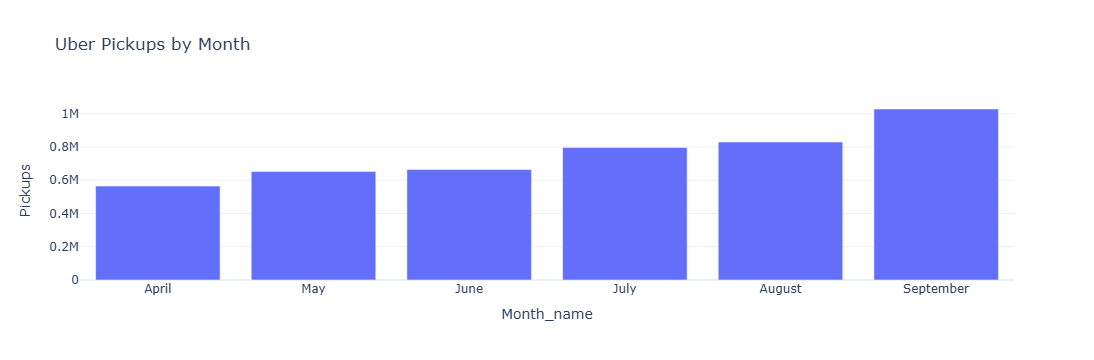

In [37]:
fig=px.bar(
    monthly_distribution,
    x="Month_name",
    y="Pickups",
    title="Uber Pickups by Month")
fig.update_layout(template='plotly_white')
fig.show()

In [39]:
## Q4: How does hourly pickup behaviour differ between weekdays and weekends?
df.head(1)

,Date/Time,Lat,Lon,Base,Hour,day,Month,Month_name
0,2014-04-01 00:11:00,40.769,-73.9549,B02512,0,Tuesday,4,April


In [43]:
df['day_type']=df['day'].apply(
    lambda x : "Weekend " if x in ["Saturday","Sunday"] else "Weekday")
hourly_pattern=(
    df.groupby(['Hour','day_type']).size().reset_index(name="Pickups"))
hourly_pattern

,Hour,day_type,Pickups
0,0,Weekday,43326
1,0,Weekend,60510
2,1,Weekday,25023
3,1,Weekend,42204
4,2,Weekday,17719
5,2,Weekend,28146
6,3,Weekday,28148
7,3,Weekend,20139
8,4,Weekday,42010
9,4,Weekend,13220


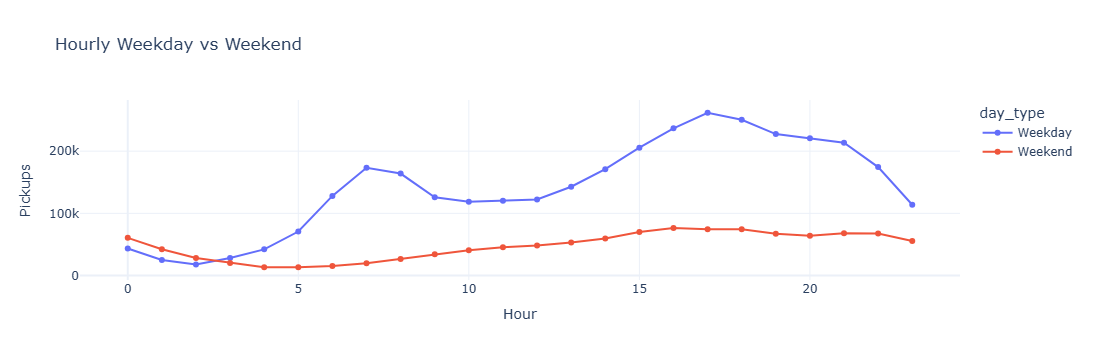

In [45]:
fig=px.line(
    hourly_pattern,
    x="Hour",
    y="Pickups",
    color="day_type",
    markers=True,
    title="Hourly Weekday vs Weekend")
fig.update_layout(template='plotly_white')
fig.show()

In [ ]:
## Q5: How are Uber pickups geographically distributed across NYC?
fig=px.density_mapbox(
    df,
    lat="Lat",
    lon="Lon",
    radius=10,
    zoom=10,
    height=600,
    title="Uber Pickup Density"
)
fig.update_layout(mapbox_style='open-street-map')
fig.show()

In [50]:
## Q6: Are there specific locations with consistently high pickup density?
df['Lat_bin']=df['Lat'].round(2)
df['Lon_bin']=df['Lon'].round(2)

In [51]:
df.head(1)

,Date/Time,Lat,Lon,Base,Hour,day,Month,Month_name,day_type,Lat_bin,Lon_bin
0,2014-04-01 00:11:00,40.769,-73.9549,B02512,0,Tuesday,4,April,Weekday,40.77,-73.95


In [52]:
location_density=(
    df.groupby(['Lat_bin','Lon_bin']).size().reset_index(name="Pickups").sort_values("Pickups",ascending=False))

In [53]:
top_location=location_density.head(10)
top_location

,Lat_bin,Lon_bin,Pickups
2441,40.76,-73.98,226692
2442,40.76,-73.97,215585
2197,40.74,-73.99,192517
2317,40.75,-73.99,172188
1949,40.72,-74.00,167633
2318,40.75,-73.98,159776
2070,40.73,-74.00,158561
2071,40.73,-73.99,141765
2196,40.74,-74.00,135782
2440,40.76,-73.99,120829


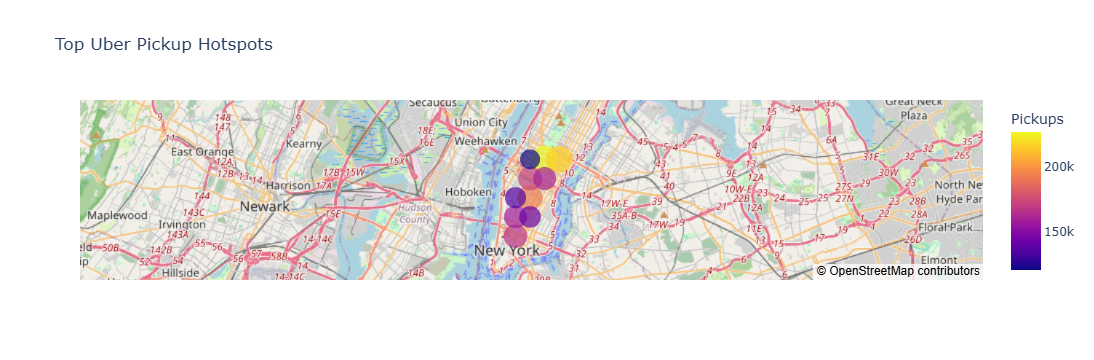

In [55]:
fig = px.scatter_mapbox(
    top_location,
    lat='Lat_bin',
    lon='Lon_bin',
    size='Pickups',
    color='Pickups',
    zoom=10,
    title="Top Uber Pickup Hotspots"
)
fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [58]:
## Q7: How does pickup volume vary across different Uber bases?
base_distribution=df.groupby('Base').size().reset_index(name="Pickups").sort_values('Pickups',ascending=False)
base_distribution

,Base,Pickups
2,B02617,1458853
1,B02598,1393113
3,B02682,1212789
4,B02764,263899
0,B02512,205673


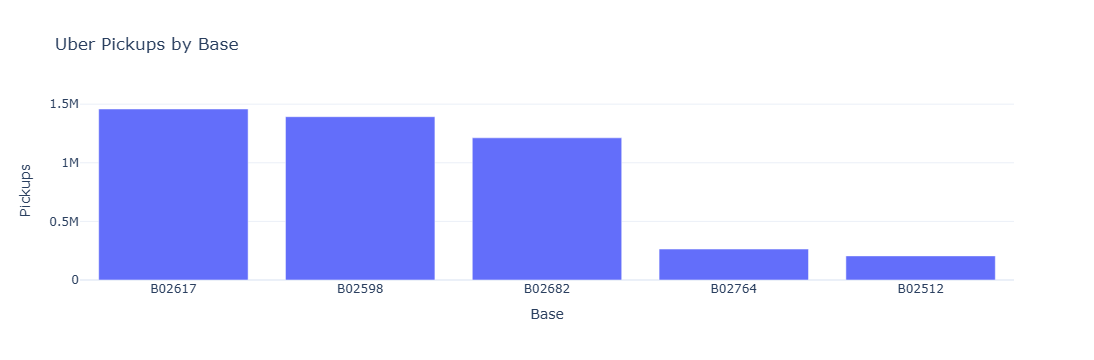

In [59]:
fig=px.bar(
    base_distribution,
    x="Base",
    y="Pickups",
    title="Uber Pickups by Base")
fig.update_layout(template="plotly_white")
fig.show()

In [60]:
## Q8: How does time of day affect pickup density across locations?
def time_bucket(hour):
    if 0<=hour<=6:
        return "Late Night"
    elif 6 <= hour<=12:
        return "Morning"
    elif 12<=hour<18:
        return "Afternoon"
    else:
        return "Evening"
df['Time_Period']=df["Hour"].apply(time_bucket)

In [61]:
import plotly.express as px

fig = px.density_mapbox(
    df,
    lat='Lat',
    lon='Lon',
    z=None,
    radius=8,
    zoom=10,
    animation_frame='Time_Period',   
    height=700,
    title="Pickup Density Across Time of Day"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

TypeError: density_mapbox() got an unexpected keyword argument 'facet_col'

In [37]:
## Q9: How does pickup activity change during late-night hours compared to daytime?
df['Hour']=df['Date/Time'].dt.hour
def day_segment(hour):
    if 0<=hour<=6:
        return "Late Night"
    else:
        return "Daytime"
df["Segment"]=df["Hour"].apply(day_segment)

In [38]:
segments_counts=df.groupby("Segment").size().reset_index(name="Pickups")
segments_counts

,Segment,Pickups
0,Daytime,3986730
1,Late Night,547597


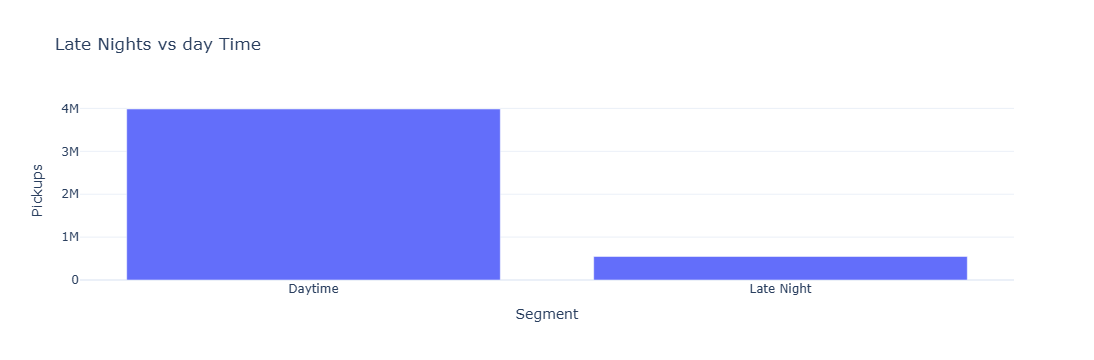

In [40]:
fig=px.bar(
    segments_counts,
    x="Segment",
    y="Pickups",
    title="Late Nights vs day Time")
fig.update_layout(template="plotly_white")
fig.show()

In [41]:
hourly_segment=df.groupby(["Hour","Segment"]).size().reset_index(name="Pickups")

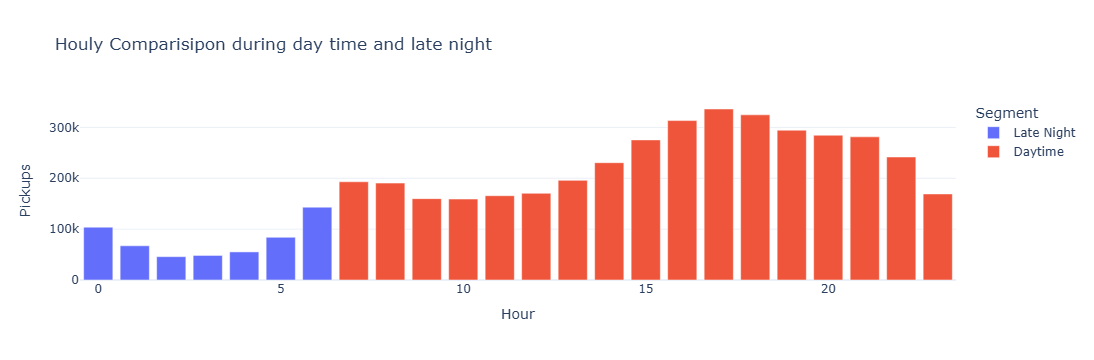

In [42]:
fig=px.bar(hourly_segment,
           x="Hour",
           y="Pickups",
           color="Segment",
           title="Houly Comparisipon during day time and late night")
fig.update_layout(template="plotly_white")
fig.show()

In [43]:
## Q10: How do pickup patterns differ between weekdays and weekends geographically?
df.head(1)

,Date/Time,Lat,Lon,Base,Hour,day,Month,Month_name,day_type,Lat_bin,Lon_bin,Time_Period,Segment
0,2014-04-01 00:11:00,40.769,-73.9549,B02512,0,Tuesday,4,April,Weekday,40.77,-73.95,Late Night,Late Night


In [ ]:
fig=px.density_mapbox(
    df,
    lat="Lat",
    lon="Lon",
    radius=8,
    zoom=10,
    animation_frame="day_type",
    title="Geographical Pickuo"
)
fig.update_layout(mapbox_style="open-street-map)
                  fig.show

In [46]:
## Q11: How does pickup frequency vary across different dates?
df["date"]=df['Date/Time'].dt.date

In [48]:
daily_pickups=df.groupby("date").size().reset_index(name="Pickups").sort_values("date")

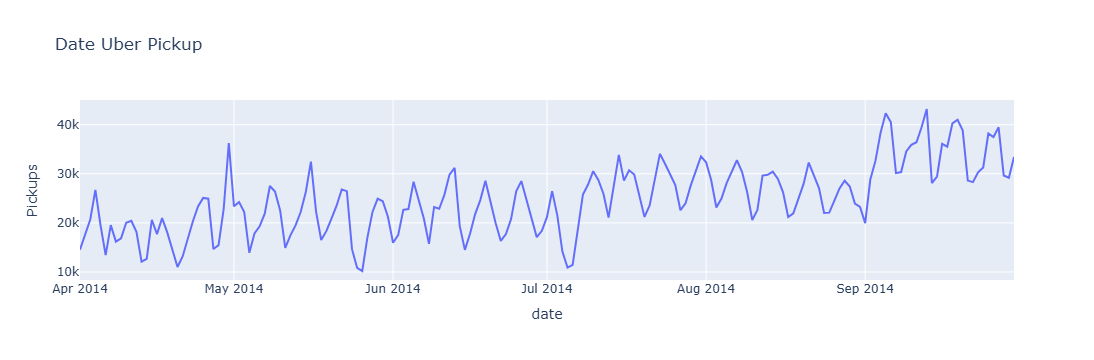

In [49]:
fig=px.line(
    daily_pickups,
    x="date",
    y="Pickups",
    title="Date Uber Pickup"
)
fig.show()

In [50]:
## Q12: Are there noticeable spikes or drops in pickup activity over time?
daily_pickups["Rolling_Avg"]=daily_pickups["Pickups"].rolling(window=3).mean()

In [54]:
daily_pickups

,date,Pickups,Rolling_Avg,Deviation
0,2014-04-01,14546,NaN,NaN
1,2014-04-02,17474,NaN,NaN
2,2014-04-03,20701,17573.666667,3127.333333
3,2014-04-04,26714,21629.666667,5084.333333
4,2014-04-05,19521,22312.000000,-2791.000000
...,...,...,...,...
178,2014-09-26,37504,35669.333333,1834.666667
179,2014-09-27,39468,38391.666667,1076.333333
180,2014-09-28,29656,35542.666667,-5886.666667
181,2014-09-29,29201,32775.000000,-3574.000000


In [55]:
from scipy.stats import zscore
daily_pickups['zscore']=zscore(daily_pickups["Pickups"])
spikes=daily_pickups[daily_pickups['zscore']<2]
drops=daily_pickups[daily_pickups['zscore']<-2]
print(spikes)
print(drops)


           date  Pickups   Rolling_Avg    Deviation    zscore
0    2014-04-01    14546           NaN          NaN -1.453505
1    2014-04-02    17474           NaN          NaN -1.037558
2    2014-04-03    20701  17573.666667  3127.333333 -0.579136
3    2014-04-04    26714  21629.666667  5084.333333  0.275062
4    2014-04-05    19521  22312.000000 -2791.000000 -0.746764
..          ...      ...           ...          ...       ...
177  2014-09-25    38203  33273.333333  4929.666667  1.907170
178  2014-09-26    37504  35669.333333  1834.666667  1.807871
180  2014-09-28    29656  35542.666667 -5886.666667  0.692997
181  2014-09-29    29201  32775.000000 -3574.000000  0.628361
182  2014-09-30    33431  30762.666667  2668.333333  1.229268

[175 rows x 5 columns]
          date  Pickups  Rolling_Avg  Deviation    zscore
55  2014-05-26    10202      11898.0    -1696.0 -2.070607


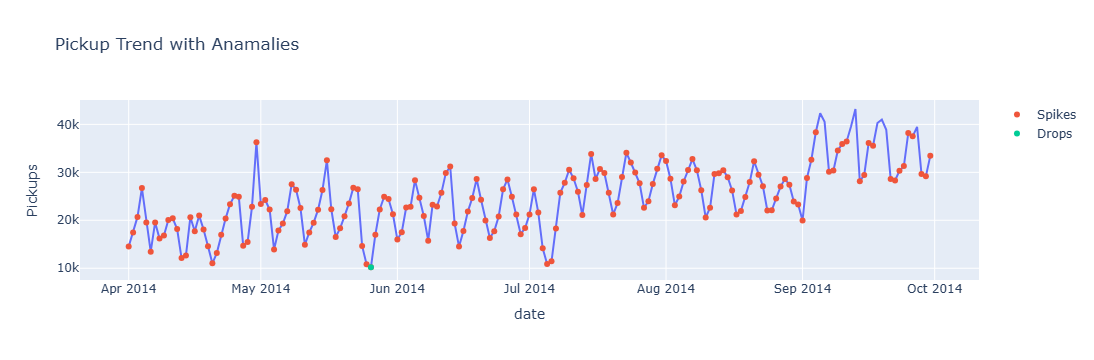

In [57]:
fig=px.line(
    daily_pickups,
    x="date",
    y="Pickups",
    title="Pickup Trend with Anamalies")
fig.add_scatter(
    x=spikes["date"],
    y=spikes["Pickups"],
    mode="markers",
    name="Spikes")
fig.add_scatter(
    x=drops["date"],
    y=drops["Pickups"],
    mode="markers",
    name="Drops")
fig.show()

In [59]:
## Q13: How does pickup volume evolve throughout a single day?
hourly_pattern=df.groupby("Hour").size().reset_index(name="Pickups").sort_values("Hour")

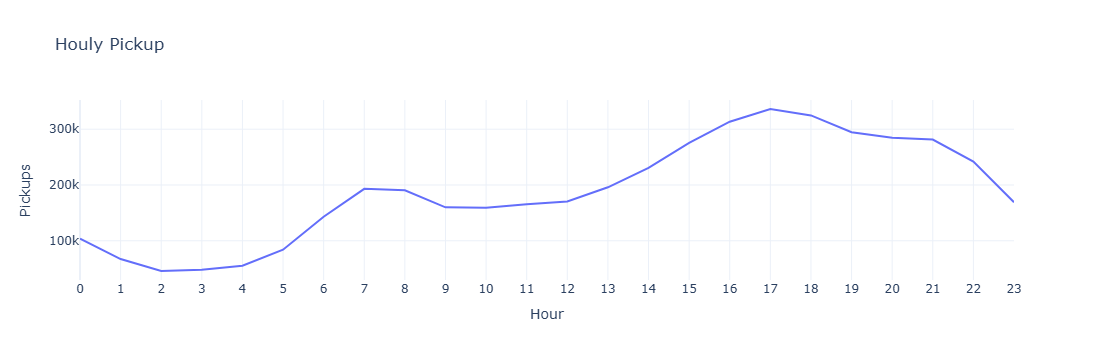

In [61]:
fig=px.line(
    hourly_pattern,
    x="Hour",
    y="Pickups",
    title="Houly Pickup")
fig.update_layout(
    template="plotly_white",
    xaxis=dict(tickmode="linear"))
fig.show()

In [66]:
## Q14: Are there seasonal patterns visible in Uber pickup activity?
daily_pickups["date"]=pd.to_datetime(daily_pickups["date"])
daily_pickups.set_index("date",inplace=True)

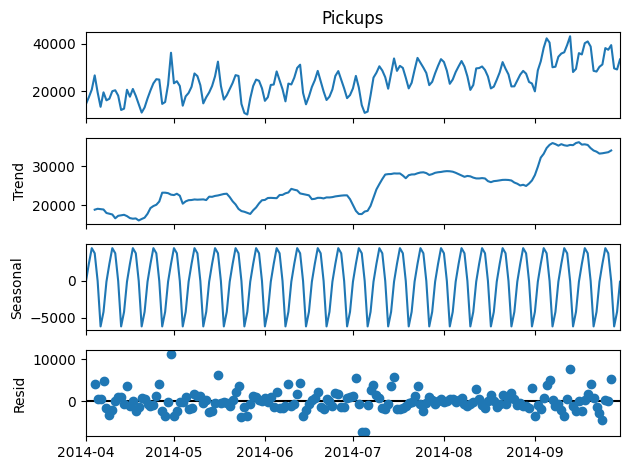

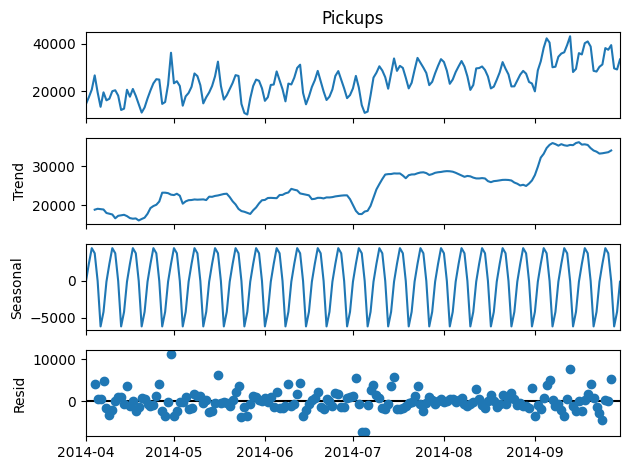

In [67]:
from statsmodels.tsa.seasonal import seasonal_decompose
res=seasonal_decompose(
    daily_pickups["Pickups"],
    model="additive",
    period=7)
res.plot()

In [69]:
## Q15: Are there identifiable patterns or clusters when considering time, location, and pickup frequency together?
from sklearn.cluster import KMeans
coords=df[['Lat','Lon']]
kmeans=KMeans(n_clusters=5,random_state=42)
df["Cluster"]=kmeans.fit_predict(coords)

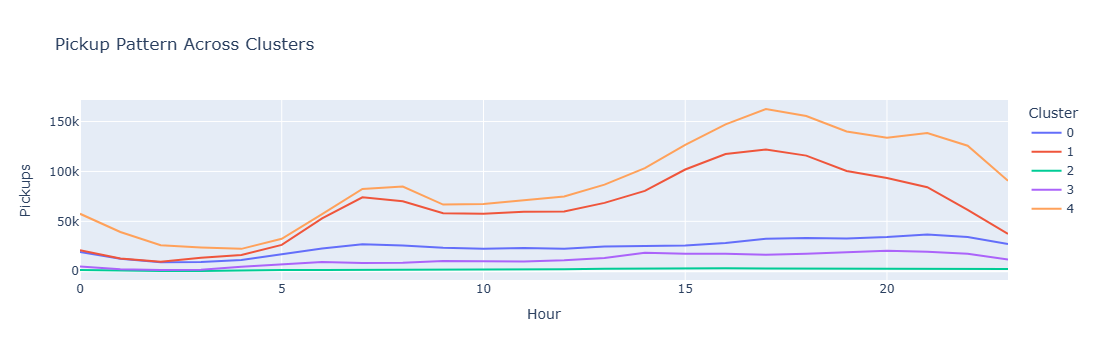

In [70]:
cluster_time=(
    df.groupby(["Cluster","Hour"]).size().reset_index(name="Pickups")
)
fig=px.line(
    cluster_time,
    x="Hour",
    y="Pickups",
    color="Cluster",
    title="Pickup Pattern Across Clusters")
fig.show()